### Time to get your hands dirty! Fun with Gamma Ray Bursts.

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



#### Python tip. Web request and smarter file reading

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [108]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names= np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])


In [109]:
# 13 dimensions
print(names)
data

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


array([['GRB251105C*', 'GRB251105B', 'GRB251105A', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['GRB251105782', 'None', 'GRB251105195', ..., 'None', 'None',
        'None'],
       ['18:45:37.622', '0:58:34', '4:41:00.769', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['29.6960', '-999', '65.2810', ..., '3.1360', '208.5760',
        '5.6960'],
       ['True', 'False', 'True', ..., 'False', 'False', 'False'],
       ['60984.78168544', '60984.04067130', '60984.19514779', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      dtype='<U14')

In [ ]:

T90=np.array(data[6],dtype=float)
T90 = T90[T90>0] #T90 is set to -999. when unknown
print(T90)
print(len(T90))
print(np.sum(T90==-999))

[ 29.696  65.281  47.553 ...   3.136 208.576   5.184]
7746
0


# Single component analysis: T90

The duration during which 90% of the burst's gamma-ray emission occurs

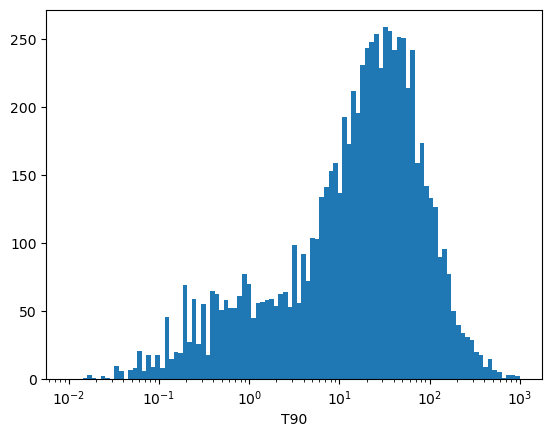

In [215]:
#linspace
# bins = np.linspace(0, 1000, 100)
# plt.xlabel("T90")
# plt.hist(T90, bins=bins)
# plt.show()

#logspace
bins=np.logspace(-2, 3, 100)
plt.hist(T90, bins=bins)
plt.xlabel("T90")
plt.xscale("log")
plt.show()

In [216]:
#organising data
grb=dict(zip(names,data))
for lab in ['T90',"redshift","T90_error"]:
    grb[lab] = np.array(grb[lab],dtype='float')

In [217]:
lT90 = np.log10(grb['T90'])
lT90=lT90[~np.isnan(lT90)]
# xcikit-learn format
skT90 = lT90[:,np.newaxis]

/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_4640/588329924.py:1: RuntimeWarning: invalid value encountered in log10
  lT90 = np.log10(grb['T90'])


# KDE

[]

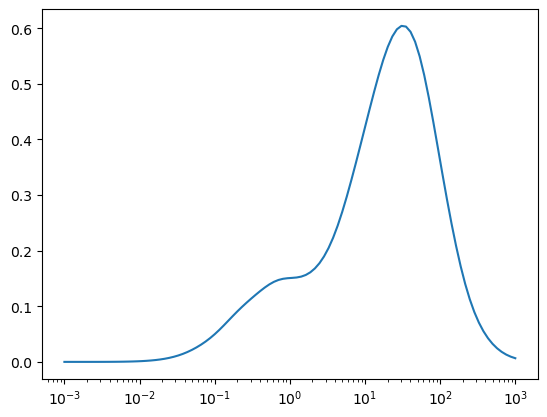

In [223]:
from sklearn.neighbors import KernelDensity
# Fit 
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(skT90) #fit the model to the data

xgrid=np.logspace(-3,3,100)
# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

#plotting
plt.plot(xgrid, ygrid)
plt.semilogx()

[1 1 1 ... 0 1 0]


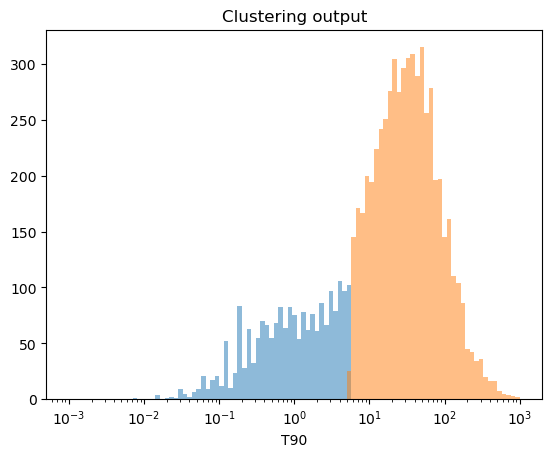

In [236]:
from sklearn.cluster import KMeans

n_clusters = 2


clf = KMeans(n_clusters=n_clusters, n_init='auto') 
clf.fit(skT90)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(skT90) #labels for each of the points

print(labels)

# plot the data color-coded by cluster id
for i in range(2):
    plt.hist(T90[labels==i], bins=xgrid, alpha=0.5)
plt.xscale("log")



# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output')
plt.xlabel("T90")
plt.show()

In [235]:
centers = clf.cluster_centers_ #location of the clusters
centers = 10**np.squeeze(centers)
centers #in seconds

array([32.59463753,  0.88102835])

Let's try (log) gaussians

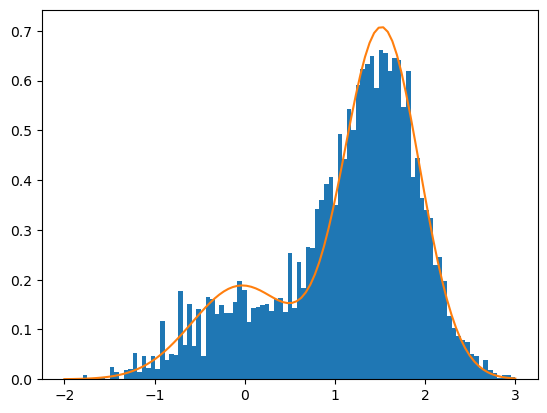

In [260]:
xgrid = np.linspace(-2, 3, 100)
plt.hist(lT90, bins=xgrid, density=True);

w1 = np.sum(labels)/len(labels)
w0 = 1 - w1

ygrid1 = w0*stats.norm(loc=clf.cluster_centers_[0], scale = np.std(lT90[labels==0])).pdf(xgrid) + w1*stats.norm(loc=clf.cluster_centers_[1], scale = np.std(lT90[labels==1])).pdf(xgrid)

plt.plot(xgrid, ygrid1)


